In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors
import seaborn as sns

In [2]:
num_states = 80

In [3]:
emissions = pd.read_csv("models/revision/5kbp/emissions_%d.txt" % num_states, sep='\t', index_col=0)

In [4]:
cpgs = [item for item in emissions.columns if "cpg" in item]
emissions[cpgs] = 1 - emissions[cpgs]

In [5]:
meta = [item.replace("4-7m", "4~7m").replace("_CpG", "").replace("bican_2025_", "").replace("_contact_strength_CPM", "").replace("-", "_") for item in emissions.columns]

In [6]:
meta_items = []
for m in meta:
    items = m.split('_')
    first = items[:3]
    mid = items[3:-1]
    last = items[-1]
    mid_item = '-'.join(mid)
#     if first[1] == "Glial":
#         if mid_item == "RG":
#             first[2] = "GPC"
#         else:
#             first[2] = mid_item
    meta_items.append(first + [mid_item] + [last])

In [7]:
meta = pd.DataFrame(meta_items)

In [8]:
age_ordered = ["2T", "3T", "1m", "4~7m", "adult"]

In [9]:
l1_ordered = ["NN", "Glial", "Exc", "Inh"]
l2_ordered = ["NN", "ODC", "OPC", "Astro", "GPC", "RG", "UL", "DL", "CA", "DG", "CGE", "MGE", "MSN"]

In [10]:
meta[0] = pd.Categorical(meta[0], categories=age_ordered, ordered=True)

In [11]:
meta["sample"] = emissions.columns
meta["age"] = [age_ordered.index(item) for item in meta[0]]
meta["L1"] = [l1_ordered.index(item) for item in meta[1]]
meta["L2"] = [l2_ordered.index(item) for item in meta[2]]
meta["assay"], _ = pd.factorize(meta[4])

In [12]:
o1 = [4, "L1", "L2", "age", 3]
# o2 = [4, "age", "L1", "L2", 3]
# o3 = [4, "L1", "L2", 3, "age"]
meta_sorted = meta.sort_values(o1)
# meta_sorted = meta

In [13]:
meta_sorted["label"] = meta_sorted[0].astype(str) + '_' + meta_sorted[1].astype(str) + '_' + meta_sorted[2].astype(str) + '_' + meta_sorted[3].astype(str)

In [14]:
l2_colors = pd.read_csv("L2_color_codes.csv", index_col=0).loc[l2_ordered]
# new_colors = [l2_colors["hex_code"][i] if l2_colors.index[i] in ["MSN", "MGE", "CGE"] else "#ffffff" for i in range(len(l2_colors))]
l2_colors["new_color"] = l2_colors["hex_code"]
l2_cmap = matplotlib.colors.ListedColormap([l2_colors.loc[item]["new_color"] for item in l2_ordered])

In [15]:
def add_borders(width, height, linewidth=3, heightpad=0.03, widthpad=0.3):
    plt.axhline(0.01, color="black", linewidth=linewidth)
    plt.axhline(height - heightpad, color="black", linewidth=linewidth)
    plt.axvline(0.01, color="black", linewidth=linewidth)
    plt.axvline(width - widthpad, color="black", linewidth=linewidth)

In [16]:
title_size = 65
annot_size = 40
neworder = np.arange(1, 81)

In [17]:
chromhmm = pd.read_csv("models/revision/5kbp/enrichments/chromhmm.txt", sep='\t', index_col=0)
enrichments = chromhmm.loc[chromhmm.index[:-1]][chromhmm.columns[1:]]
enrichments.columns = [item.split('.')[0] for item in enrichments.columns]
enrichments.index = np.arange(1, 81)
cols = enrichments.columns
state_num = [int(item.split('_')[0]) for item in cols]
enrichments = enrichments[[enrichments.columns[state_num.index(item)] for item in range(0, 100)]]
col_norm = (enrichments - enrichments.min()) / (enrichments.max() - enrichments.min())

In [18]:
chromhmm_meta = pd.read_csv("state_annotations_processed.csv")
chromhmm_meta.index = chromhmm_meta["mneumonics"]
chromhmm_meta = chromhmm_meta.loc[[item.split('_')[1] for item in enrichments.columns]]
chromhmm_colors = matplotlib.colors.ListedColormap(chromhmm_meta["color"])

In [19]:
chip_atlas_raw = pd.read_csv("chip-atlas_median_5kbp_revision.csv", index_col=0, sep='\t')

In [20]:
# neworder = list(pd.read_csv("2025_chromHMM_states_variable.txt", header=None)[0])
neworder = np.arange(1, 81)

In [21]:
chip_atlas = chip_atlas_raw.loc[neworder].dropna(axis=1, how="all")

In [22]:
brainspan_tfs = list(pd.read_csv("tf/brainspan_rpkm5_list.txt", header=None, index_col=None)[0])
chip_atlas = chip_atlas[[item for item in chip_atlas.columns if item in brainspan_tfs]]

In [23]:
for top_k in range(1, len(chip_atlas.columns)):
    top_chip = []
    for index, row in chip_atlas.iterrows():
        try:
            tops = row[~row.isna()].sort_values(ascending=False).index
            cnt = 0
            for item in tops:
                if item not in top_chip:
                    top_chip.append(item)
                    cnt += 1
                if cnt == top_k:
                    break
        except IndexError:
            continue
    unique_chip = list(dict.fromkeys(top_chip))
    if len(unique_chip) == len(chip_atlas.columns):
        break

In [24]:
unique_chip = [item for item in unique_chip if item not in ["Epitope tags", "T"]]

In [25]:
title_size = 65
annot_size = 40

In [26]:
neworder = emissions.index

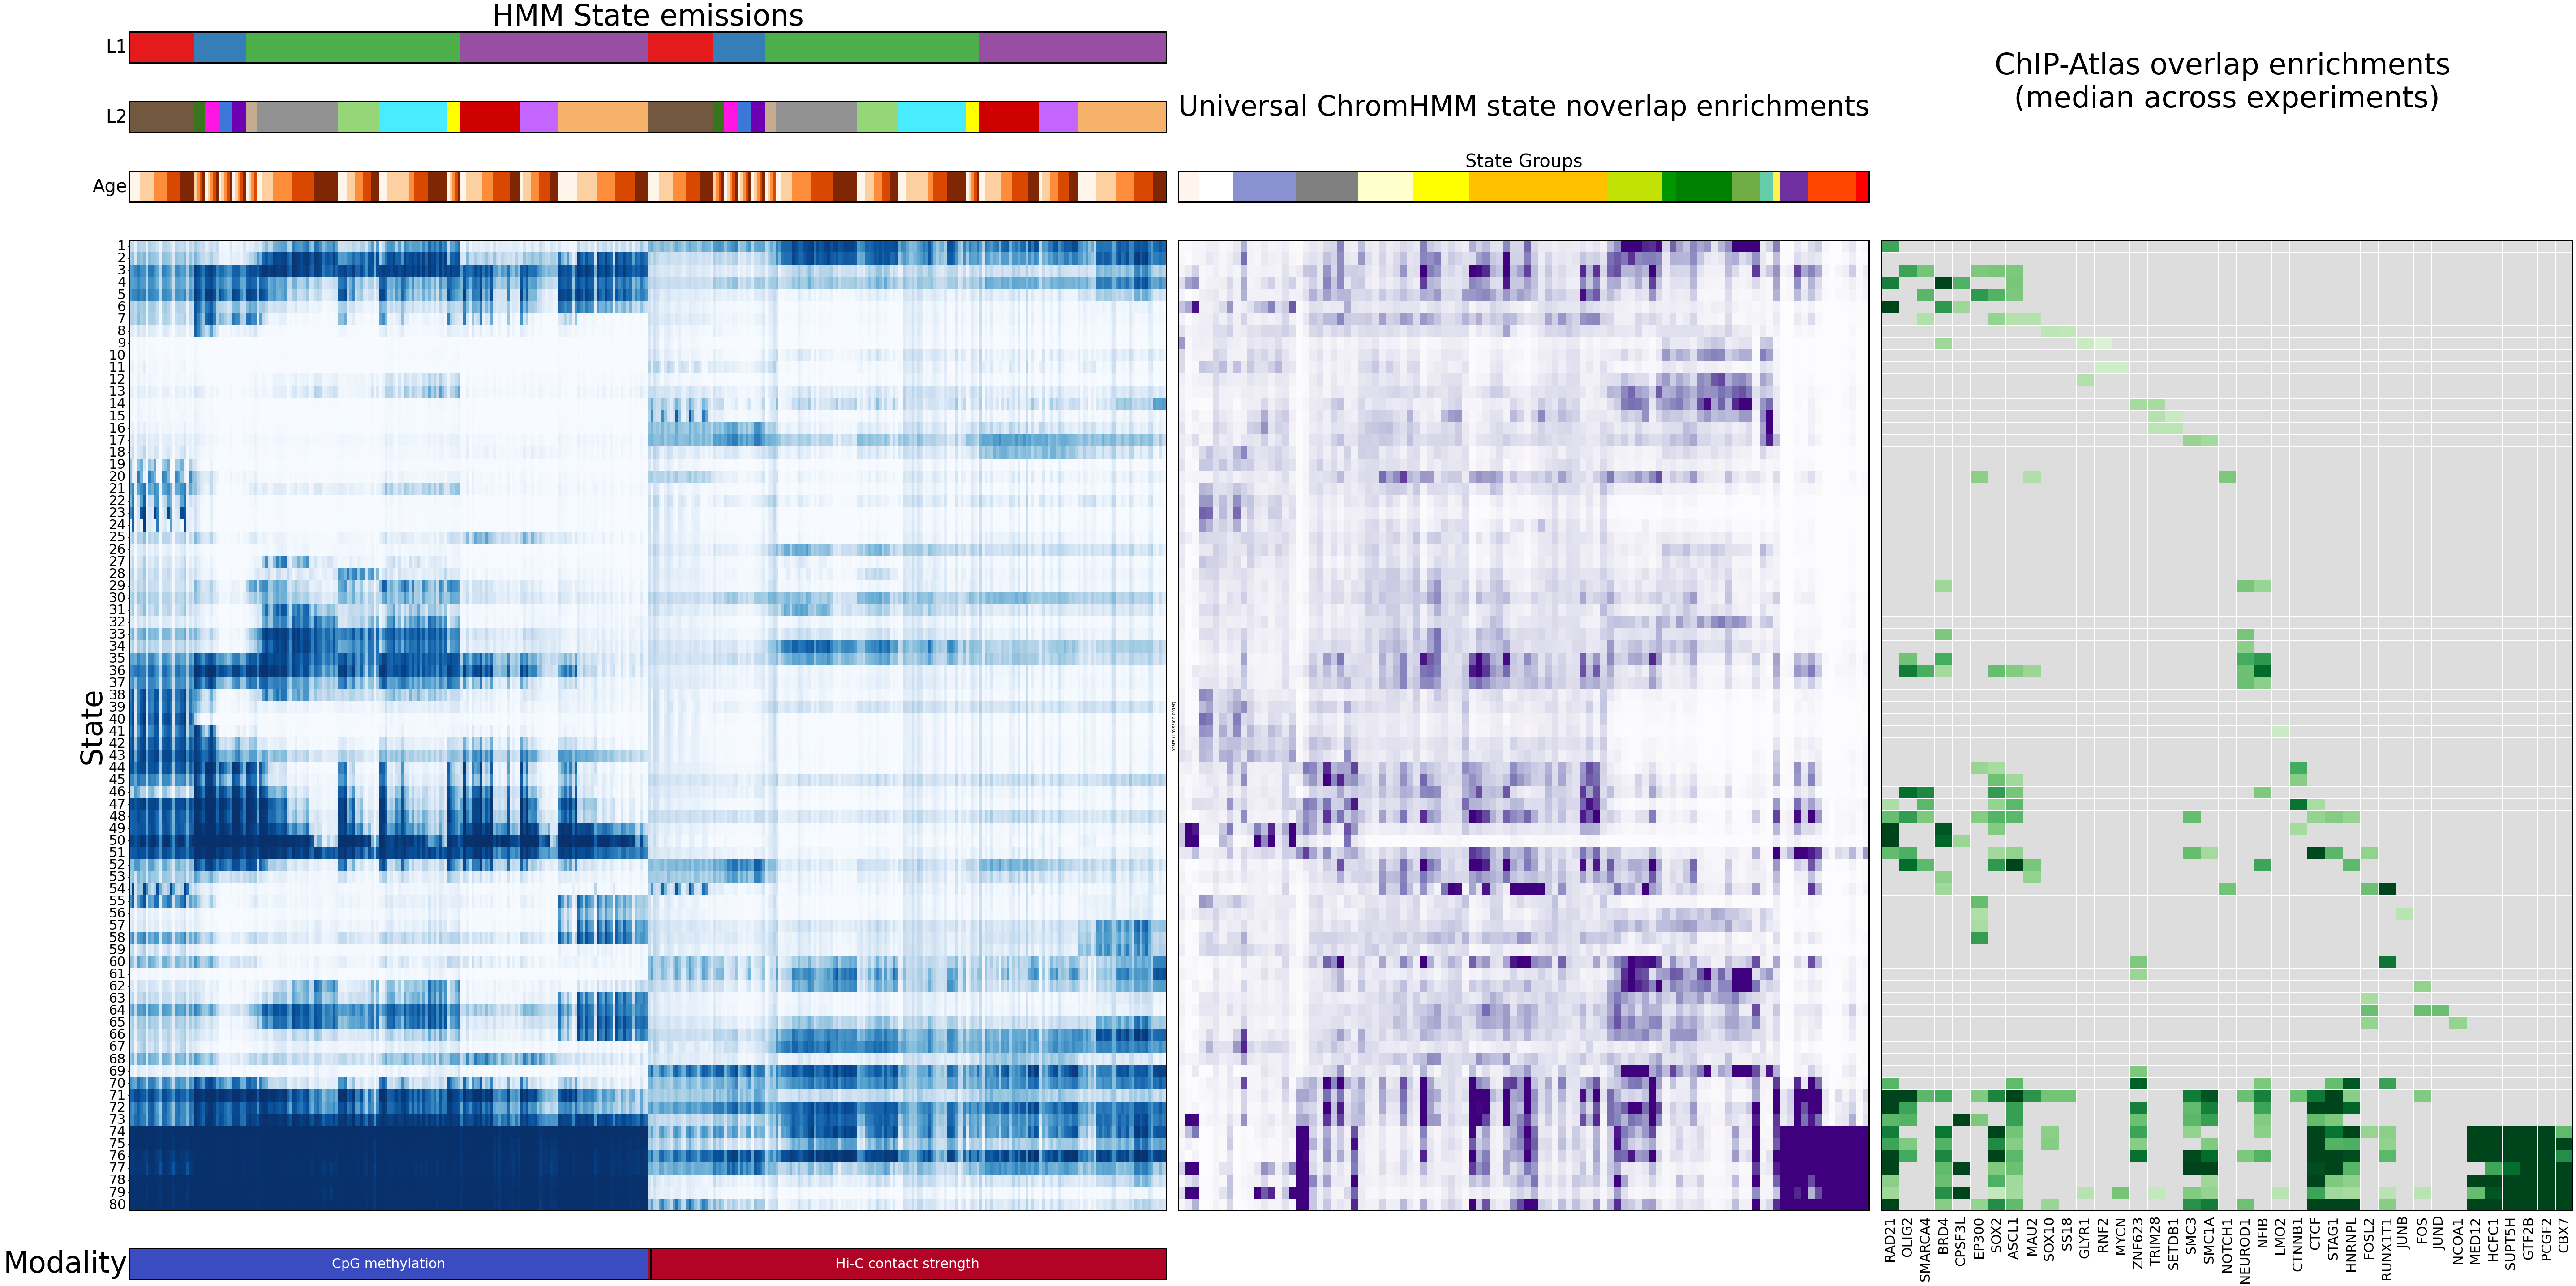

In [27]:
fig = plt.figure(figsize=(80, 40), layout="tight")
gs = gridspec.GridSpec(nrows=5, ncols=3, width_ratios=[15, 10, 10], height_ratios=[1, 1, 1, 30, 1])

# Main emissions
plt.subplot(gs[0, 0])
sns.heatmap(meta_sorted["L1"].values.reshape(1, -1), cbar=None, cmap="Set1", vmin=0, vmax=7, rasterized=True)
plt.yticks([])
plt.ylabel("L1", rotation=0, size=annot_size, horizontalalignment="right", verticalalignment="center")
plt.xticks([])
plt.title("HMM State emissions", size=title_size)
add_borders(len(emissions.columns), 1)

plt.subplot(gs[1, 0])
sns.heatmap(meta_sorted["L2"].values.reshape(1, -1), cbar=None, cmap=l2_cmap, rasterized=True)
plt.yticks([])
plt.ylabel("L2", rotation=0, size=annot_size, horizontalalignment="right", verticalalignment="center")
plt.xticks([])
add_borders(len(emissions.columns), 1)

plt.subplot(gs[2, 0])
sns.heatmap(meta_sorted["age"].values.reshape(1, -1), cbar=None, cmap="Oranges", rasterized=True)
plt.yticks([])
plt.ylabel("Age", rotation=0, size=annot_size, horizontalalignment="right", verticalalignment="center")
plt.xticks([])
add_borders(len(emissions.columns), 1)


plt.subplot(gs[3, 0]) 
sns.heatmap(emissions.loc[neworder][meta_sorted["sample"]], cbar=None, cmap="Blues", rasterized=True)
# for i in range(1, len(neworder) + 1):
#     plt.axhline(i, color="white", linewidth=0.75)
plt.yticks(size=30, rotation=0)
plt.ylabel("State", size=title_size)
plt.xticks([])
add_borders(len(emissions.columns), len(neworder))


plt.subplot(gs[4, 0]) 
sns.heatmap(meta_sorted["assay"].values.reshape(1, -1) ,cbar=None, cmap="coolwarm_r", vmin=0, vmax=1, rasterized=True)
plt.yticks([])
plt.ylabel("Modality", rotation=0, size=title_size, horizontalalignment="right", verticalalignment="center")
plt.xticks([])
add_borders(len(emissions.columns), 1)
plt.axvline(len(emissions.columns) / 2 + 1, color="black", linewidth=3)


assay_name = {"cpg": "CpG methylation", "hic": "Hi-C contact strength"}

plt.text(x=len(emissions.columns) / 4, y=0.5, s=assay_name[list(meta_sorted[4])[0]], 
         size=30, color="white", va="center", ha="center")
plt.text(x=len(emissions.columns) * 3 / 4, y=0.5, s=assay_name[list(meta_sorted[4])[-1]], 
        size=30, color="white", va="center", ha="center")


plt.subplot(gs[1, 1], frameon=False)
plt.text(x=0.5, y=0.8, s="Universal ChromHMM state noverlap enrichments", size=title_size - 3, va="center", ha="center")
# plt.title("Universal ChromHMM state \n overlap enrichments", size=35)
plt.yticks([])
plt.xticks([])

plt.subplot(gs[2, 1])
sns.heatmap(np.arange(0, 100).reshape(1, -1), cbar=None, cmap=chromhmm_colors, vmin=0, vmax=100, rasterized=True)
plt.yticks([])
plt.xticks([])
plt.title("State Groups", size=annot_size)
add_borders(len(enrichments.columns), 1, widthpad=0.2)

plt.subplot(gs[3, 1])
sns.heatmap(enrichments.loc[neworder], cmap="Purples", vmin=0, vmax=5, cbar=None, rasterized=True)
plt.yticks([])
plt.xticks([])
add_borders(len(enrichments.columns), len(neworder), widthpad=0.2)

#chip atlas
plt.subplot(gs[0:2, 2], frameon=False)
plt.text(x=0.5, y=0.5, s="ChIP-Atlas overlap enrichments \n(median across experiments)", size=title_size, va="center", ha="center")
plt.yticks([])
plt.xticks([])

plt.subplot(gs[3, 2])
cmap = plt.get_cmap("Greens")
cmap.set_bad("#dddddd") 
sns.heatmap(chip_atlas[unique_chip].loc[neworder], cmap=cmap, 
            mask=pd.isna(chip_atlas[unique_chip].loc[neworder]), 
            vmin=0, vmax=10, cbar=None, linewidths=0.5, linecolor="white", rasterized=True)
plt.yticks([])
plt.ylabel("")
plt.xticks([])
add_borders(len(unique_chip), len(neworder), widthpad=0.01)


plt.subplot(gs[4, 2], frameon=False)
for i in range(0, len(unique_chip)):
    s = unique_chip[i]
    plt.text(x=((i + 0.5)/ len(unique_chip)), y=2, s=s, 
             rotation=90, size=30, va="top", ha="center")
plt.yticks([])
plt.xticks([])
plt.savefig("plots/figure_5kbp_rpkm5_revision.svg", dpi=fig.dpi)

In [40]:
# vanilla = pd.read_csv("models/200bp_new/enrichments/vanilla.txt", sep='\t', index_col=0)
# vanilla = vanilla.loc[vanilla.index[:-1]]
# vanilla.index = np.arange(1, 81)
# vanilla.columns = [item.split('.')[0] for item in vanilla.columns]
# vanilla_col_norm = (vanilla - vanilla.min()) / (vanilla.max() - vanilla.min())

In [24]:
# overlap = pd.read_csv("models/200bp_new/Genome_%d_overlap.txt" % num_states, sep='\t', index_col=0)

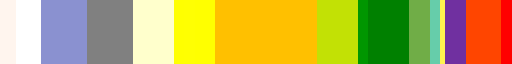

In [25]:
chromhmm_colors

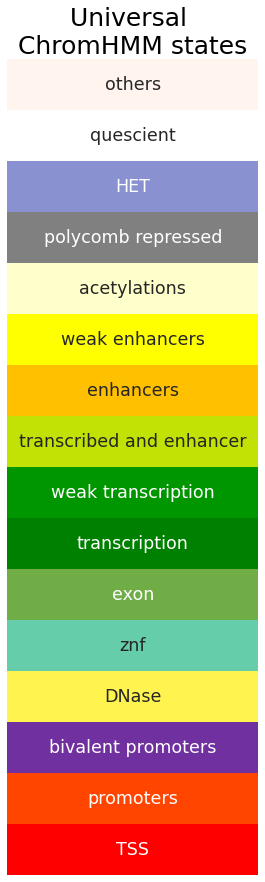

In [60]:
plt.figure(figsize=(4.5, 15))
groups = chromhmm_meta["Group"].unique()
group_colors = [chromhmm_meta[chromhmm_meta["Group"] == item]["color"][0] for item in groups]
group_colors = matplotlib.colors.ListedColormap(group_colors)
sns.heatmap(np.arange(len(groups)).reshape(-1, 1), 
            cbar=False, cmap=group_colors, 
            annot=np.asarray(groups).reshape(-1, 1), fmt="s", 
           annot_kws={"size": 17.5}, rasterized=True)
plt.xticks([])
plt.yticks([])
plt.title("Universal \nChromHMM states", size=25)
plt.savefig("plots/legend_chromhmm.svg", dpi=fig.dpi)

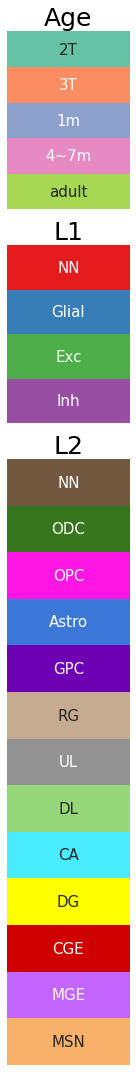

In [59]:
plt.figure(figsize=(2, 15))
plt.subplot(15, 1, (1, 3))
sns.heatmap(np.arange(len(age_ordered)).reshape(-1, 1), 
            cbar=False, cmap="Set2", vmin=0, vmax=7, 
            annot=np.asarray(age_ordered).reshape(-1, 1), fmt="s", 
           annot_kws={"size": 15}, rasterized=True)
plt.xticks([])
plt.yticks([])
plt.title("Age", size=25)

plt.subplot(15, 1, (4, 6))
sns.heatmap(np.arange(len(l1_ordered)).reshape(-1, 1), 
            cbar=False, cmap="Set1", vmin=0, vmax=7, 
            annot=np.asarray(l1_ordered).reshape(-1, 1), fmt="s", 
           annot_kws={"size": 15}, rasterized=True)
plt.xticks([])
plt.yticks([])
plt.title("L1", size=25)

plt.subplot(15, 1, (7, 15))
sns.heatmap(np.arange(len(l2_ordered)).reshape(-1, 1), 
            cbar=False, cmap=l2_cmap, 
            annot=np.asarray(l2_ordered).reshape(-1, 1), fmt="s", 
           annot_kws={"size": 15}, vmin=0, vmax=len(l2_ordered), rasterized=True)
plt.xticks([])
plt.yticks([])
plt.title("L2", size=25)
plt.tight_layout()
plt.savefig("plots/legend_emissions.svg", dpi=fig.dpi)